<a href="https://colab.research.google.com/github/Adeela-saleem/MachineLearning_Algorithms/blob/main/Supervised_Learning/Regression/lasso_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import make_regression


In [ ]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)


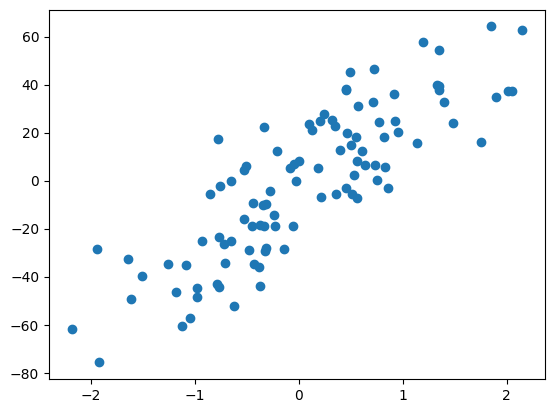

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X,y)



In [ ]:
from sklearn.linear_model import LinearRegression


In [ ]:
reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

[28.0069442]
-3.06986180710226


In [ ]:
from sklearn.linear_model import Lasso

# Alpha parameter (regularization strength / penalty term) specify karein
# Alpha = 0 hone par ye normal Linear Regression jaisa hi behave karega
# Alpha jitna zyada hoga, coefficients utne hi shrink (zero ki taraf) honge
alpha = 1.0  # Aap 0.1, 1.0, 5.0 wagera adjust karke check kar sakte hain

lasso_reg = Lasso(alpha=alpha)
lasso_reg.fit(X_train, y_train)

# Coefficient aur Intercept print karein
print("Lasso Coefficient:", lasso_reg.coef_)
print("Lasso Intercept:", lasso_reg.intercept_)

# Model performance (R² score) check karne ke liye:
print("Train Score:", lasso_reg.score(X_train, y_train))
print("Test Score:", lasso_reg.score(X_test, y_test))

Lasso Coefficient: [26.91572297]
Lasso Intercept: -2.953692081082555
Train Score: 0.714737912628435
Test Score: 0.633148958011493


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.141e+04, tolerance: 8.033e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

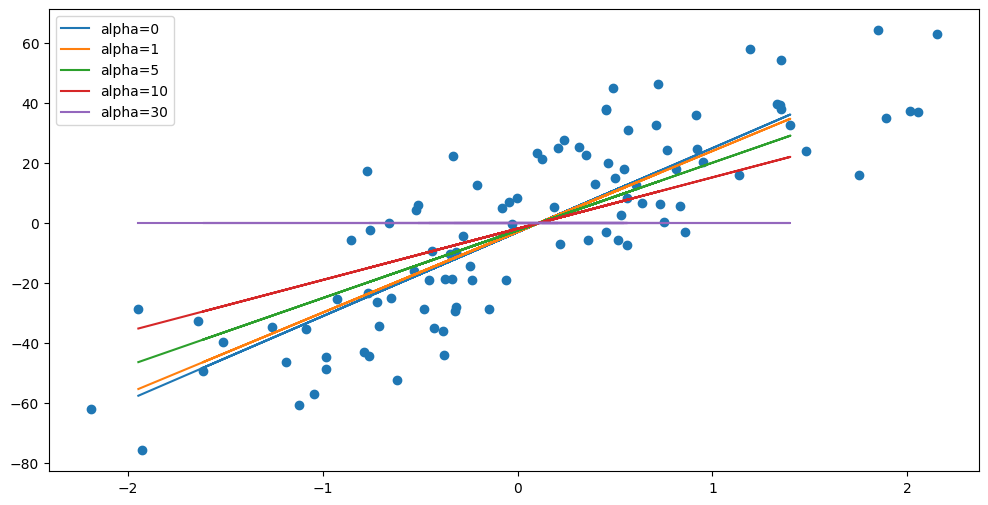

In [ ]:

alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i))
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LassoCV

# LassoCV automatically best alpha select karta hai
lasso_cv = LassoCV(cv=5).fit(X_train, y_train)

print("Best Alpha Value:", lasso_cv.alpha_)
print("Best Model Score:", lasso_cv.score(X_test, y_test))

Best Alpha Value: 0.22322706915030482
Best Model Score: 0.632025836887675


In [ ]:
# Best alpha ke sath final model fit karein
final_lasso = Lasso(alpha=lasso_cv.alpha_)
final_lasso.fit(X_train, y_train)

# Final model ka coefficient aur score print karein
print("Final Coefficient:", final_lasso.coef_)
print("Final Test R2 Score:", final_lasso.score(X_test, y_test))

Final Coefficient: [27.76335409]
Final Test R2 Score: 0.632025836887675


## Summary: Lasso Regression Analysis

1. **Dataset Creation:**
   `make_regression` se single-feature continuous dataset generate kiya aur train/test split (80/20) apply kiya.

2. **Model Comparison (Linear vs Lasso):**
   - **Linear Regression:** `coef_ = 28.00`, `intercept = -3.06`
   - **Lasso Regression (`alpha=1.0`):** `coef_ = 26.91`, `Test R² = 0.633` (Alpha lagane se coefficient shrink hona start hua).

3. **Hyperparameter Effect (Alpha Plotting):**
   - Different alpha values (`0, 1, 5, 10, 30`) test kiye gaye.
   - High alpha values (`30`) par line flat ho gayi (coefficients zero ho gaye), jo **Underfitting** show karti hai.

4. **Optimal Alpha Selection:**
   - `LassoCV(cv=5)` se optimal parameter find kiya gaya: **`Best Alpha ≈ 0.223`**.

5. **Final Model Performance:**
   - **Final Coefficient:** `27.76`
   - **Final Test R² Score:** `0.632`